# Visualisation of the three scenarios

This notebook loads the CSV files produced by the `A_calibration`, `B_stress_sybil`, `C_bootstrap` scenarios, generates the graphs side by side, and offers a reading.

It expects to find the most recent results in `simulateur/results/<scenario>/<timestamp>/`.

In [1]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

BASE = os.path.abspath(os.path.join(os.getcwd(), "..", "results"))

def load_latest(scenario):
    paths = sorted(glob.glob(os.path.join(BASE, scenario, "*")))
    if not paths:
        raise FileNotFoundError(f"No results for {scenario}. Run the scenario first.")
    p = paths[-1]
    return {
        "path": p,
        "ticks": pd.read_csv(os.path.join(p, "metrics_per_tick.csv")),
        "agents": pd.read_csv(os.path.join(p, "agents_final.csv")),
        "network": pd.read_csv(os.path.join(p, "network.csv")),
    }

scenarios = {
    "A_calibration":  load_latest("A_calibration"),
    "B_stress_sybil": load_latest("B_stress_sybil"),
    "C_bootstrap":    load_latest("C_bootstrap"),
}

for name, d in scenarios.items():
    print(f"{name:<18} → {d['path']}")
    print(f"  ticks={d['ticks'].tick.max()}, n_agents={d['agents'].shape[0]}")

A_calibration      → /home/marius/Documents/MonAi/simulateur/results/A_calibration/20260510_135553
  ticks=1999, n_agents=140
B_stress_sybil     → /home/marius/Documents/MonAi/simulateur/results/B_stress_sybil/20260510_135608
  ticks=1999, n_agents=300
C_bootstrap        → /home/marius/Documents/MonAi/simulateur/results/C_bootstrap/20260510_135640
  ticks=1499, n_agents=20


## §1 — Reliability `f̂` trajectories per profile

The red threshold at 0.80 marks the zone where `M(f, d) ≈ 0` on easy tasks: below this threshold, the agent is mechanically crushed.

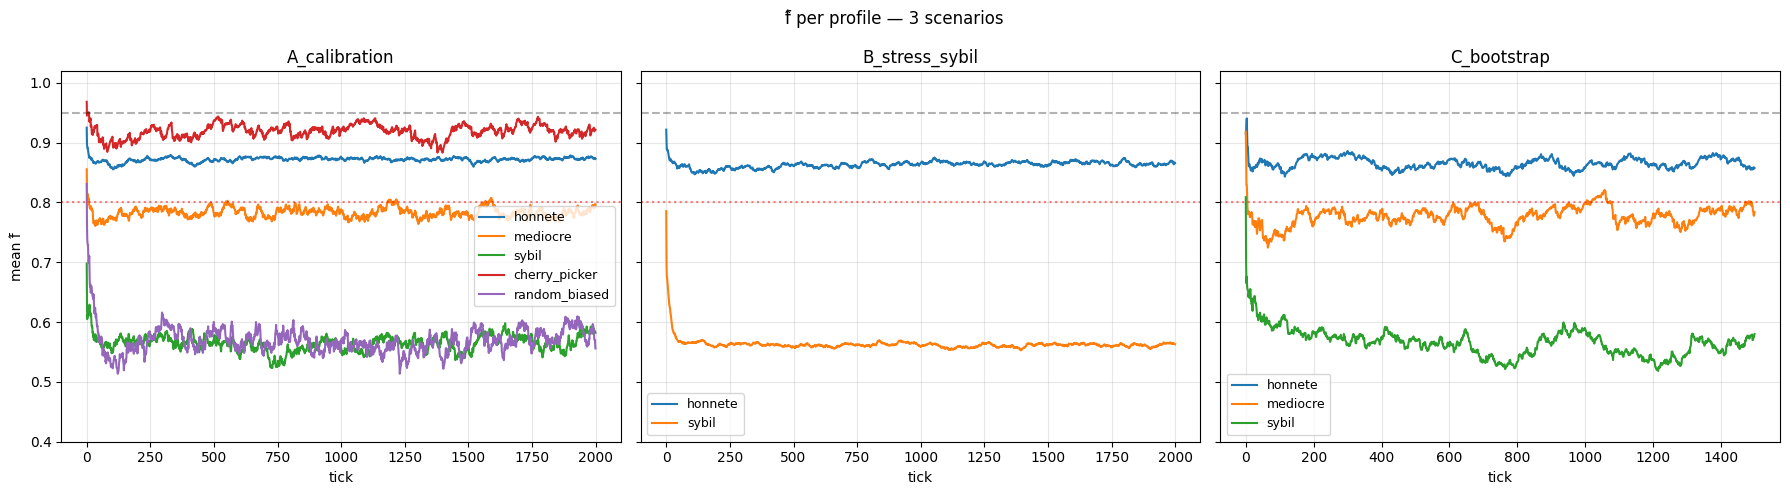

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (name, d) in zip(axes, scenarios.items()):
    df = d["ticks"]
    for profile in df["profile"].unique():
        sub = df[df["profile"] == profile]
        ax.plot(sub["tick"], sub["f_hat_mean"], label=profile)
    ax.axhline(0.80, color="red", linestyle=":", alpha=0.5)
    ax.axhline(0.95, color="black", linestyle="--", alpha=0.3)
    ax.set_xlabel("tick")
    ax.set_title(name)
    ax.legend(fontsize=9)
axes[0].set_ylabel("mean f̂")
axes[0].set_ylim(0.4, 1.02)
fig.suptitle("f̂ per profile — 3 scenarios")
plt.tight_layout()
plt.show()

**Reading**: in the three scenarios, the sybil and random_biased agents drop quickly toward ~0.55-0.60 and stay below the threshold. Honest and cherry-picker converge toward ~0.87-0.92. The mediocre stagnates at ~0.80, just above the threshold — it survives but with a narrow margin. With the linear `p_correct(θ)` degradation, difficulty pulls the average f̂ down for all non-perfect profiles.

## §2 — Reputation score `R` per profile

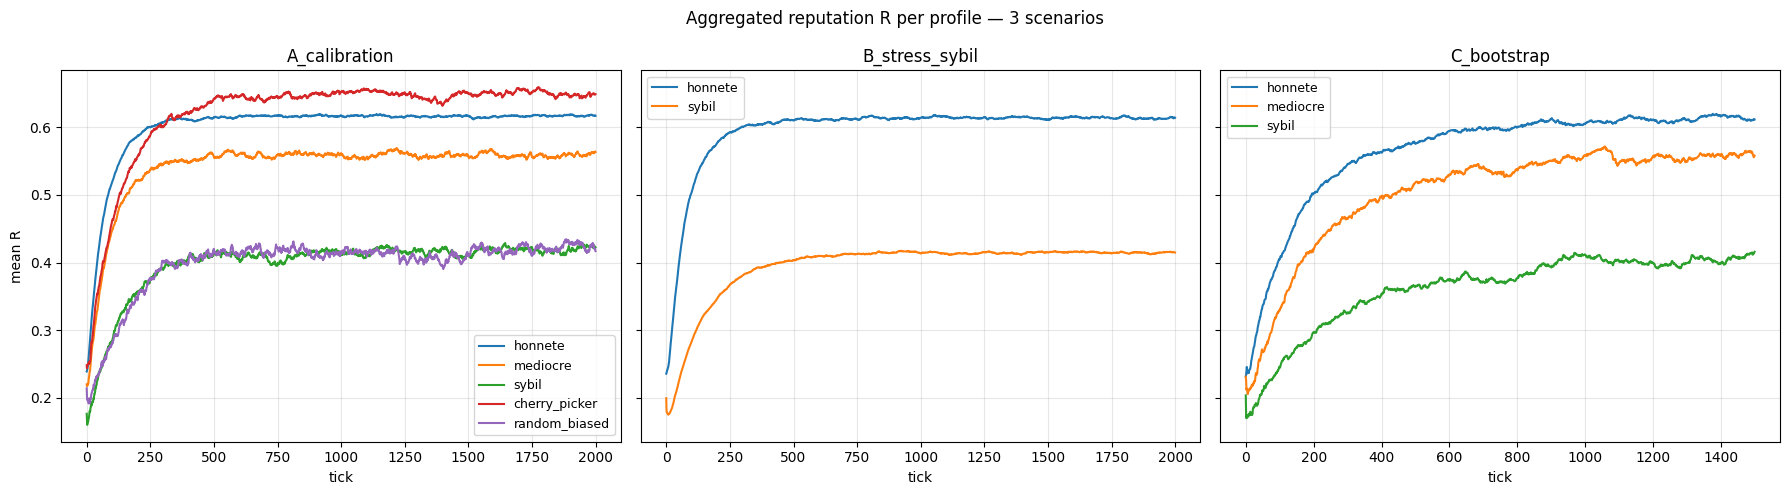

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (name, d) in zip(axes, scenarios.items()):
    df = d["ticks"]
    for profile in df["profile"].unique():
        sub = df[df["profile"] == profile]
        ax.plot(sub["tick"], sub["R_mean"], label=profile)
    ax.set_xlabel("tick")
    ax.set_title(name)
    ax.legend(fontsize=9)
axes[0].set_ylabel("mean R")
fig.suptitle("Aggregated reputation R per profile — 3 scenarios")
plt.tight_layout()
plt.show()

**Reading**: R inherits the dynamics of f̂ (via the `R_V = f̂` component at 25 % weight) and of `R_C` (correct validations EWMA, 35 % weight). The gap between profiles is more pronounced on R than on f̂ because `R_C` accumulates faster with activity volume.

## §3 — Cumulative gains per profile

This is the strategic test: the gain hierarchy must reflect behavior quality.

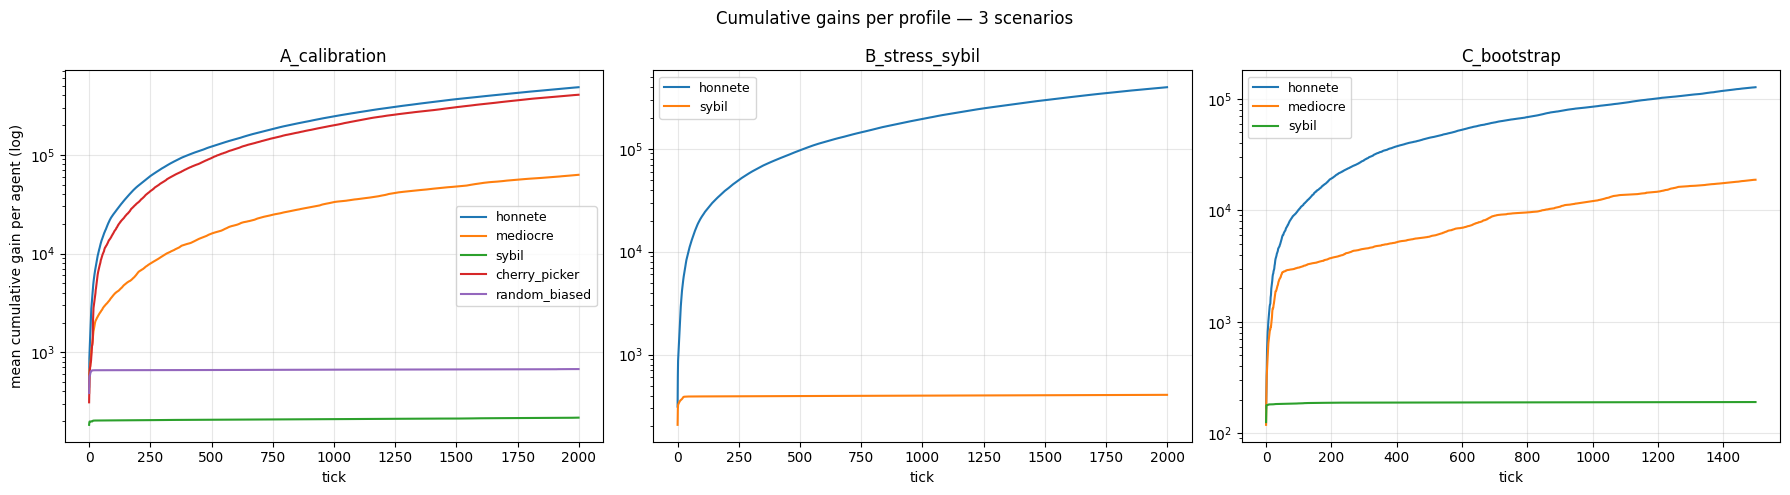


Final ranking (mean cumulative gain per agent):

  A_calibration
    honnete               484849
    cherry_picker         406694
    mediocre               62796
    random_biased            675
    sybil                    217

  B_stress_sybil
    honnete               396618
    sybil                    406

  C_bootstrap
    honnete               127325
    mediocre               18834
    sybil                    191



In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, d) in zip(axes, scenarios.items()):
    df = d["ticks"]
    for profile in df["profile"].unique():
        sub = df[df["profile"] == profile]
        ax.plot(sub["tick"], sub["cum_reward_mean"], label=profile)
    ax.set_xlabel("tick")
    ax.set_yscale("log")
    ax.set_title(name)
    ax.legend(fontsize=9)
axes[0].set_ylabel("mean cumulative gain per agent (log)")
fig.suptitle("Cumulative gains per profile — 3 scenarios")
plt.tight_layout()
plt.show()

# Final summary table
print("\nFinal ranking (mean cumulative gain per agent):\n")
for name, d in scenarios.items():
    last = d["ticks"].groupby("profile").tail(1).sort_values("cum_reward_mean", ascending=False)
    print(f"  {name}")
    for _, r in last.iterrows():
        print(f"    {r.profile:<15} {r.cum_reward_mean:>12.0f}")
    print()

**Reading**:

- **Scenario A**: honest > cherry-picker > mediocre > random_biased ≈ sybil. The cherry-picker overtakes the mediocre — this is an effect of the **linear `p_correct(θ)` degradation** retained (Q1 of the plan): a mediocre agent at `p_base=0.85` sees its `p_correct` drop to 0.675 on tasks at `θ=0.5`, which strongly degrades its f̂ and expels it from the rewarded zone. The cherry-picker, on the other hand, only takes easy tasks where it stays at 0.999. To reproduce the user spec hierarchy (honest > mediocre > cherry-picker), a flat `p_correct` would be needed, or relaxing `f0_max` to 0.85 for example.

- **Scenario B**: honest crushes the sybil by **1000×** in gain per agent (~400k vs ~400). Rate-limiting and sigmoid `M(f, d)` render the massive sybil attack unprofitable, as expected.

- **Scenario C** (bootstrap): same pattern as A on a small scale. The replay pool (i) is built progressively (visible in the `pool_replay` logs), but synthetic source (iii) alone is sufficient to detect sybils from bootstrap onward.

Conclusion: the default calibration (sigmoid `f0_max=0.90, k=40, δ=0.10, γ=1`) correctly discriminates honest vs sybil, but over-penalizes the mediocre compared to the spec target. This is a calibration point to arbitrate.

## §4 — Cumulative issuance and network activity

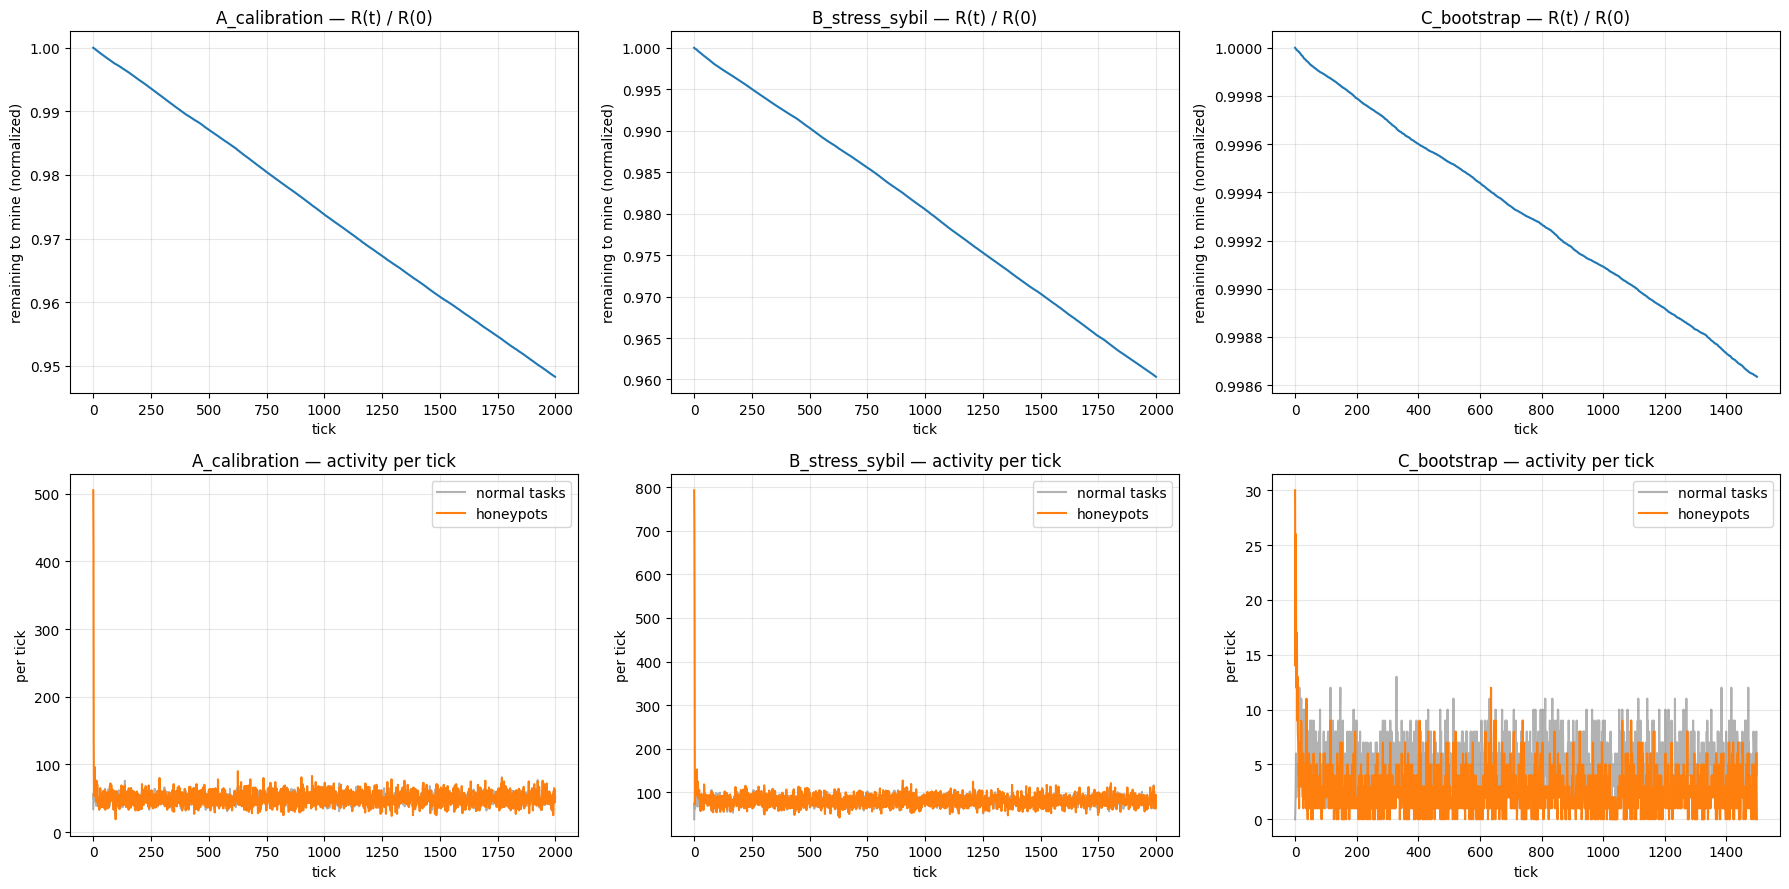

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for col, (name, d) in enumerate(scenarios.items()):
    net = d["network"]
    axes[0, col].plot(net["tick"], net["R_remaining"] / net["R_remaining"].iloc[0])
    axes[0, col].set_title(f"{name} — R(t) / R(0)")
    axes[0, col].set_xlabel("tick")
    axes[0, col].set_ylabel("remaining to mine (normalized)")

    axes[1, col].plot(net["tick"], net["n_tasks"], color="tab:gray", alpha=0.6, label="normal tasks")
    axes[1, col].plot(net["tick"], net["n_honeypots"], color="tab:orange", label="honeypots")
    axes[1, col].set_title(f"{name} — activity per tick")
    axes[1, col].set_xlabel("tick")
    axes[1, col].set_ylabel("per tick")
    axes[1, col].legend()

plt.tight_layout()
plt.show()

**Reading**: R(t) decreases linearly (in first approximation) because `k = 1e-7` is constant and the task flow is constant. Over 2000 ticks of scenario A, ~5 % of total supply is issued — consistent with an issuance curve spread over several simulated years.

The number of honeypots per tick follows the aggregate `φ_eff` fraction — high at startup due to the dense cold-start, then decreases toward `φ = 0.10` × N_validations × N_tasks/tick at steady state.

## §5 — Final distribution of `f̂` per profile (scenario A)

Histogram per profile — to verify there are no agents "lost" in an extreme tail.

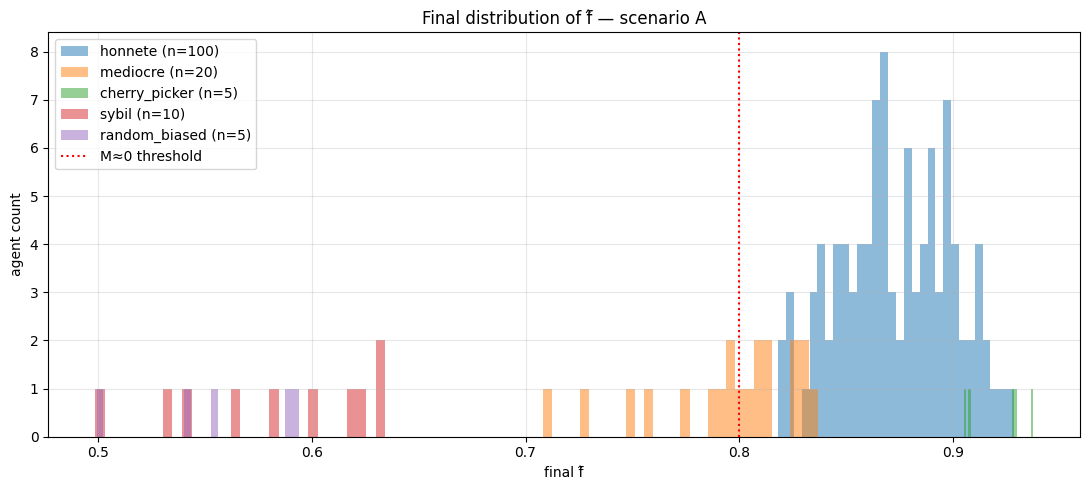

In [6]:
df_agents = scenarios["A_calibration"]["agents"]
fig, ax = plt.subplots(figsize=(11, 5))
for profile in df_agents["profile"].unique():
    sub = df_agents[df_agents["profile"] == profile]
    ax.hist(sub["f_hat_final"], bins=30, alpha=0.5, label=f"{profile} (n={len(sub)})")
ax.axvline(0.80, color="red", linestyle=":", label="M≈0 threshold")
ax.set_xlabel("final f̂")
ax.set_ylabel("agent count")
ax.set_title("Final distribution of f̂ — scenario A")
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways

1. **Gain hierarchy well-oriented**: honest in the lead, sybil and biased random crushed. The cherry-picker is an intermediate case that sometimes overtakes the mediocre — sensitive to the linear `p_correct(θ)` choice.

2. **Massive sybil (B)** is neutralized by the combination of sigmoid `M(f, d)` + rate-limiting + honeypots. Honest/sybil ratio ≈ 1000× in gain per agent.

3. **Bootstrap (C)** holds well thanks to synthetic source (iii) which does not depend on the replay pool. The replay pool is built progressively.

4. **Mediocre vs cherry-picker calibration**: the default sigmoid over-penalizes the mediocre (f̂ ≈ 0.80, low M) compared to a cherry-picker (f̂ ≈ 0.92). To test with `f0_max = 0.85` or `δ = 0.15` to see whether the spec hierarchy can be respected.

5. **R(t) decreases reasonably** — no explosion or depletion. The issuance curve is consistent.

See the simulator's `README.md` for v1 simplifications and v2 avenues.